# Filtering and Smoothing

We compare Gaussian and particle filters on state-space models:
1. **Linear Gaussian** — Kalman filter (exact), RTS smoother
2. **Nonlinear** — Extended Kalman filter, Unscented Kalman filter, Particle filter

All filters follow the same `Filter` runner API:

In [1]:
import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from functools import partial

from probjax.inference.filter_smooth import Filter
from probjax.inference.filtering.kalman_filter import kalman_filter
from probjax.inference.filtering.extended_kalman_filter import (
    extended_kalman_filter,
    make_linearized_transition,
    make_linearized_observation,
)
from probjax.inference.filtering.unscented_kalman_filter import ukf, merwe_sigma_point
from probjax.inference.filtering.particle_filter import ParticleFilter
from probjax.inference.filtering.smoothing import rauch_tung_stribel_smoother

## Linear Gaussian model

A simple 1D state-space model with known transition and observation dynamics:

$$x_{t+1} = A \, x_t + w_t, \quad w_t \sim \mathcal{N}(0, Q)$$
$$y_t = C \, x_t + v_t, \quad v_t \sim \mathcal{N}(0, R)$$

We generate synthetic data from the model, then filter and smooth.

W0418 12:17:58.433965 5943266 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


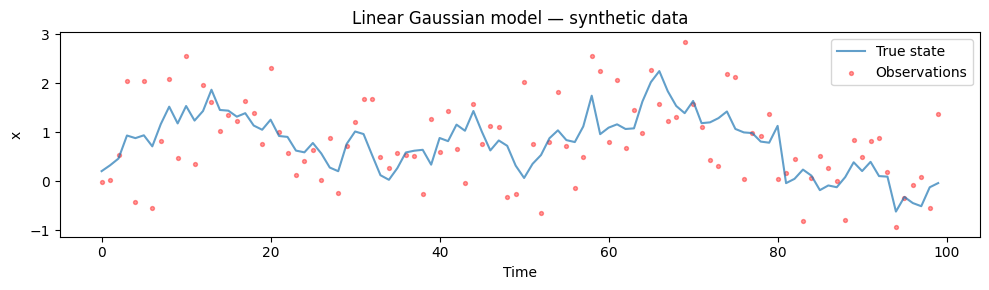

In [2]:
A = jnp.array([[0.95]])
Q = jnp.array([[0.1]])
C = jnp.array([[1.0]])
R = jnp.array([[0.5]])

mu0 = jnp.array([0.0])
cov0 = jnp.array([[1.0]])

# Transition and observation model callbacks
def transition_model(t_old, t):
    return A, Q

def observation_model(t):
    return C, R

# Generate synthetic observations
key = jax.random.PRNGKey(42)
T = 100
ts = jnp.arange(T, dtype=jnp.float32)

x_true = jnp.zeros((T, 1))
y_obs = jnp.zeros((T, 1))
x = mu0
for t in range(T):
    key, k1, k2 = jax.random.split(key, 3)
    x = A @ x + jax.random.normal(k1, (1, 1)) * jnp.sqrt(Q)
    y = C @ x + jax.random.normal(k2, (1, 1)) * jnp.sqrt(R)
    x_true = x_true.at[t].set(x[0])
    y_obs = y_obs.at[t].set(y[0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, x_true[:, 0], label="True state", alpha=0.7)
ax.scatter(ts, y_obs[:, 0], s=8, color="red", alpha=0.4, label="Observations")
ax.set_xlabel("Time"); ax.set_ylabel("x"); ax.legend()
ax.set_title("Linear Gaussian model — synthetic data")
plt.tight_layout(); plt.show()

## Kalman filter

The Kalman filter gives the exact posterior for linear Gaussian models.
We use the `Filter` runner class — analogous to `MCMC` / `SMC`.

In [3]:
kernel = kalman_filter(transition_model, observation_model)
filt = Filter(kernel)

# Create observations array and mask
# observations: values at ALL time points (dummy at t=0, actual values at t>=1)
# obs_mask: True where we have actual observations
observations = jnp.concatenate([jnp.zeros((1, 1)), y_obs[:-1]], axis=0)
obs_mask = jnp.concatenate([jnp.array([False]), jnp.ones(T-1, dtype=bool)])

trace = filt.filter(key, ts, observations, mu0, cov0, obs_mask=obs_mask)

print(f"Trace contains {trace.states.mean.shape[0]} time steps")
print(f"State dim: {trace.states.mean.shape[1]}")
print(f"Filtered means shape:  {trace.states.mean.shape}")
print(f"Filtered covs shape:   {trace.states.cov.shape}")
print(f"Predicted means shape: {trace.infos.mean_pred.shape}")

Trace contains 99 time steps
State dim: 1
Filtered means shape:  (99, 1)
Filtered covs shape:   (99, 1, 1)
Predicted means shape: (99, 1)


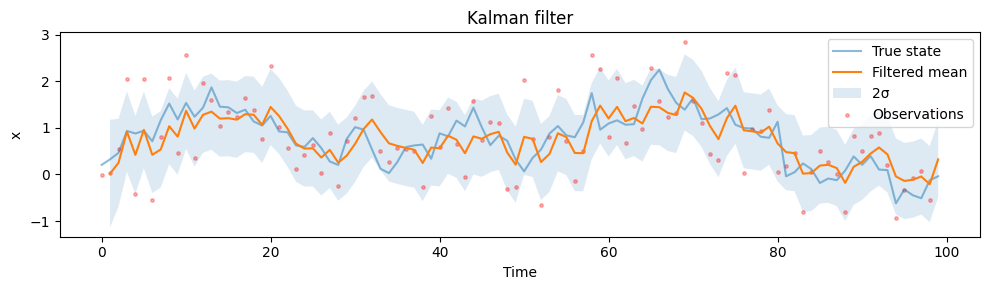

In [4]:
ts_filt = ts[1:]  # filtered outputs align with ts[1:]
mus = trace.states.mean[:, 0]
stds = jax.vmap(jnp.sqrt)(trace.states.cov[:, 0, 0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, x_true[:, 0], alpha=0.5, label="True state")
ax.plot(ts_filt, mus, label="Filtered mean")
ax.fill_between(ts_filt, mus - 2*stds, mus + 2*stds, alpha=0.15, label="2σ")
ax.scatter(ts, y_obs[:, 0], s=6, color="red", alpha=0.3, label="Observations")
ax.set_xlabel("Time"); ax.set_ylabel("x"); ax.legend()
ax.set_title("Kalman filter")
plt.tight_layout(); plt.show()

## Log-likelihood

The filter also exposes the log-likelihood of the observations under the model — useful for model selection and parameter learning.

In [5]:
ll = filt.log_likelihood(key, ts, observations, mu0, cov0, obs_mask=obs_mask)
print(f"Log-likelihood: {ll:.2f}")

Log-likelihood: -32.72


## RTS smoothing

Smoothing refines the filtered estimates by incorporating future observations.
For Gaussian filters we pass an RTS-style smoother callback.

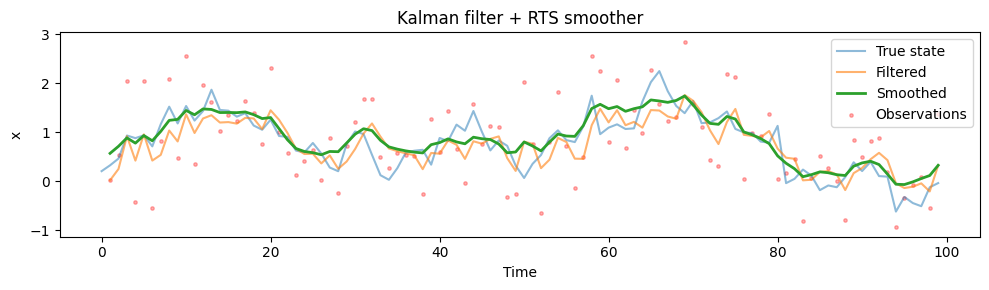

In [6]:
rts_smoother = partial(rauch_tung_stribel_smoother, lambda t0, t1: A)

mus_s, covs_s = filt.smooth(trace, smoother=rts_smoother)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, x_true[:, 0], alpha=0.5, label="True state")
ax.plot(ts_filt, trace.states.mean[:, 0], alpha=0.6, label="Filtered")
ax.plot(ts_filt, mus_s[:, 0], linewidth=2, label="Smoothed")
ax.scatter(ts_filt, x_o[:, 0], s=6, color="red", alpha=0.3, label="Observations")
ax.set_xlabel("Time"); ax.set_ylabel("x"); ax.legend()
ax.set_title("Kalman filter + RTS smoother")
plt.tight_layout(); plt.show()

## Nonlinear model

When the transition or observation model is nonlinear, we use approximate filters.
Here we define a model with nonlinear transition but linear observation:

$$x_{t+1} = 0.5\, x_t + 25 \frac{x_t}{1 + x_t^2} + 8 \cos(1.2\, t) + w_t$$
$$y_t = 0.5\, x_t + v_t$$

The linear observation preserves sign information, allowing the EKF to track the state accurately.

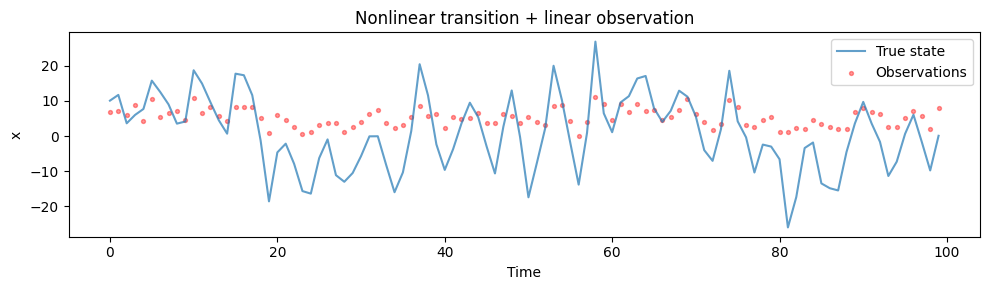

In [22]:
Q_nl = jnp.array([[10.0]])
R_nl = jnp.array([[2.0]])  # Slightly increased for linear observation

def transition_fn_nl(x, t_old, t):
    return 0.5 * x + 25.0 * x / (1.0 + x**2) + 8.0 * jnp.cos(1.2 * t_old)

def observation_fn_nl(x, t):
    return jax.nn.sigmoid(x/10.0)*10

# Generate nonlinear data
key = jax.random.PRNGKey(42)
x_true_nl = jnp.zeros((T, 1))
y_obs_nl = jnp.zeros((T, 1))
x = jnp.array([0.0])
for t in range(T):
    key, k1, k2 = jax.random.split(key, 3)
    x = transition_fn_nl(x, t, t+1) + jax.random.normal(k1, (1,)) * jnp.sqrt(Q_nl[0, 0])
    y = observation_fn_nl(x, t+1) + jax.random.normal(k2, (1,)) * jnp.sqrt(R_nl[0, 0])
    x_true_nl = x_true_nl.at[t].set(x[0])
    y_obs_nl = y_obs_nl.at[t].set(y[0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, x_true_nl[:, 0], alpha=0.7, label="True state")
ax.scatter(ts, y_obs_nl[:, 0], s=8, color="red", alpha=0.4, label="Observations")
ax.set_xlabel("Time"); ax.set_ylabel("x"); ax.legend()
ax.set_title("Nonlinear transition + linear observation")
plt.tight_layout(); plt.show()

## Extended Kalman filter

The EKF linearizes the nonlinear model at each step via Jacobians.

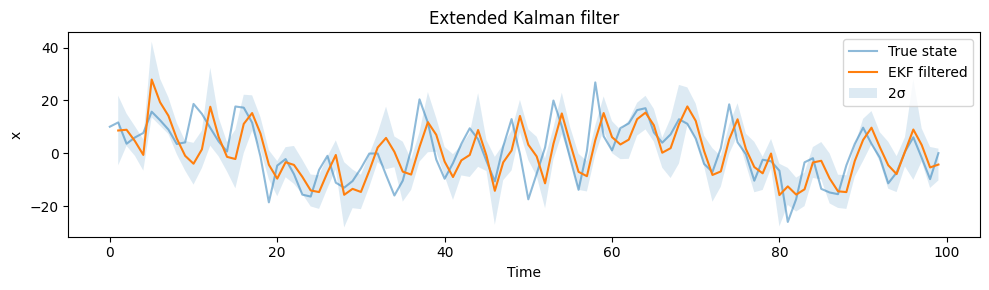

In [23]:
# Build linearized transition/observation with auto-Jacobian
# materialize=True gives dense Jacobians - better for small state dimensions
ekf_transition = make_linearized_transition(transition_fn_nl, Q_nl, in_dim=1, materialize=True)
ekf_observation = make_linearized_observation(observation_fn_nl, R_nl, in_dim=1, out_dim=1, materialize=True)

ekf_kernel = extended_kalman_filter(ekf_transition, ekf_observation)
filt_ekf = Filter(ekf_kernel)

# Create observations array and mask for nonlinear model
observations_nl = jnp.concatenate([jnp.zeros((1, 1)), y_obs_nl[:-1]], axis=0)
obs_mask_nl = jnp.concatenate([jnp.array([False]), jnp.ones(T-1, dtype=bool)])

trace_ekf = filt_ekf.filter(key, ts, observations_nl, jnp.array([0.0]), jnp.array([[10.0]]), obs_mask=obs_mask_nl)

mus_ekf = trace_ekf.states.mean[:, 0]
stds_ekf = jax.vmap(jnp.sqrt)(trace_ekf.states.cov[:, 0, 0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, x_true_nl[:, 0], alpha=0.5, label="True state")
ax.plot(ts_filt, mus_ekf, label="EKF filtered")
ax.fill_between(ts_filt, mus_ekf - 2*stds_ekf, mus_ekf + 2*stds_ekf, alpha=0.15, label="2σ")
ax.set_xlabel("Time"); ax.set_ylabel("x"); ax.legend()
ax.set_title("Extended Kalman filter")
plt.tight_layout(); plt.show()

## Unscented Kalman filter

The UKF propagates sigma points through the nonlinear model — no Jacobians needed.

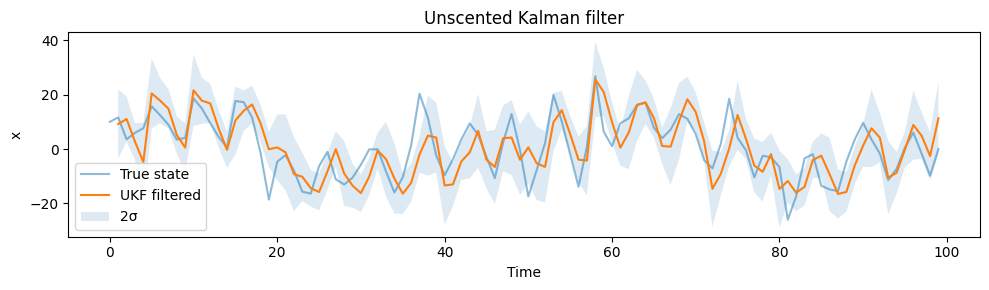

In [24]:
ukf_kernel = ukf(
    transition_fn_nl, Q_nl, observation_fn_nl, R_nl,
    sigma_point_fn=merwe_sigma_point,
)
filt_ukf = Filter(ukf_kernel)

trace_ukf = filt_ukf.filter(key, ts, observations_nl, jnp.array([0.0]), jnp.array([[10.0]]), obs_mask=obs_mask_nl)

mus_ukf = trace_ukf.states.mean[:, 0]
stds_ukf = jax.vmap(jnp.sqrt)(trace_ukf.states.cov[:, 0, 0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, x_true_nl[:, 0], alpha=0.5, label="True state")
ax.plot(ts_filt, mus_ukf, label="UKF filtered")
ax.fill_between(ts_filt, mus_ukf - 2*stds_ukf, mus_ukf + 2*stds_ukf, alpha=0.15, label="2σ")
ax.set_xlabel("Time"); ax.set_ylabel("x"); ax.legend()
ax.set_title("Unscented Kalman filter")
plt.tight_layout(); plt.show()

## Particle filter

The particle filter is fully nonparametric — it represents the posterior as a
weighted cloud of particles.  No linearization or Gaussian assumptions.

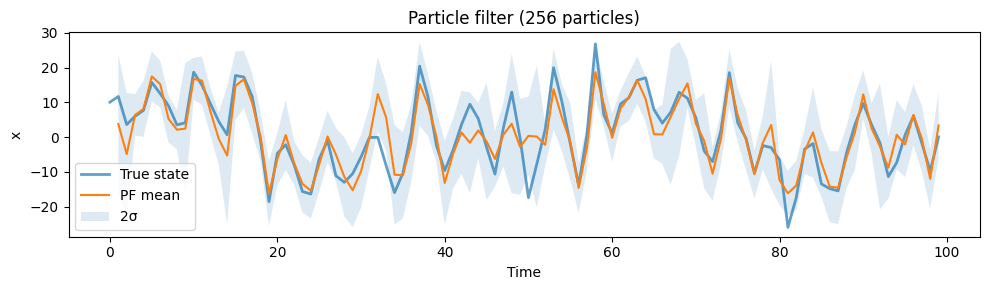

In [25]:
num_particles = 256

def pf_transition(key, particles, t):
    noise = jax.random.normal(key, particles.shape) * jnp.sqrt(Q_nl[0, 0])
    return jax.vmap(lambda x: transition_fn_nl(x, t, t+1))(particles) + noise

def pf_log_likelihood(particles, obs, t):
    y_pred = jax.vmap(lambda x: observation_fn_nl(x, t))(particles)[:, 0]
    return jax.scipy.stats.norm.logpdf(obs[0], y_pred, jnp.sqrt(R_nl[0, 0]))

pf_kernel = ParticleFilter(pf_log_likelihood, pf_transition)
filt_pf = Filter(pf_kernel)

key = jax.random.PRNGKey(0)
init_particles = jax.random.normal(key, (num_particles, 1)) * 3.0

trace_pf = filt_pf.filter(key, ts, observations_nl, init_particles, obs_mask=obs_mask_nl)

pf_mean = trace_pf.states.particles.mean(axis=1)
pf_std = trace_pf.states.particles.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, x_true_nl[:, 0], alpha=0.7, linewidth=2, label="True state")
ax.plot(ts_filt, pf_mean[:, 0], label="PF mean")
ax.fill_between(ts_filt, pf_mean[:, 0] - 2*pf_std[:, 0], pf_mean[:, 0] + 2*pf_std[:, 0], alpha=0.15, label="2σ")
ax.set_xlabel("Time"); ax.set_ylabel("x"); ax.legend()
ax.set_title("Particle filter (256 particles)")
plt.tight_layout(); plt.show()

## Particle smoothing

For particle filters, smoothing uses the FFBSi (Forward Filter-Backward Simulator)
algorithm.  We pass a `transition_logdensity_fn` that evaluates $\log p(x_{t+1} \mid x_t)$.

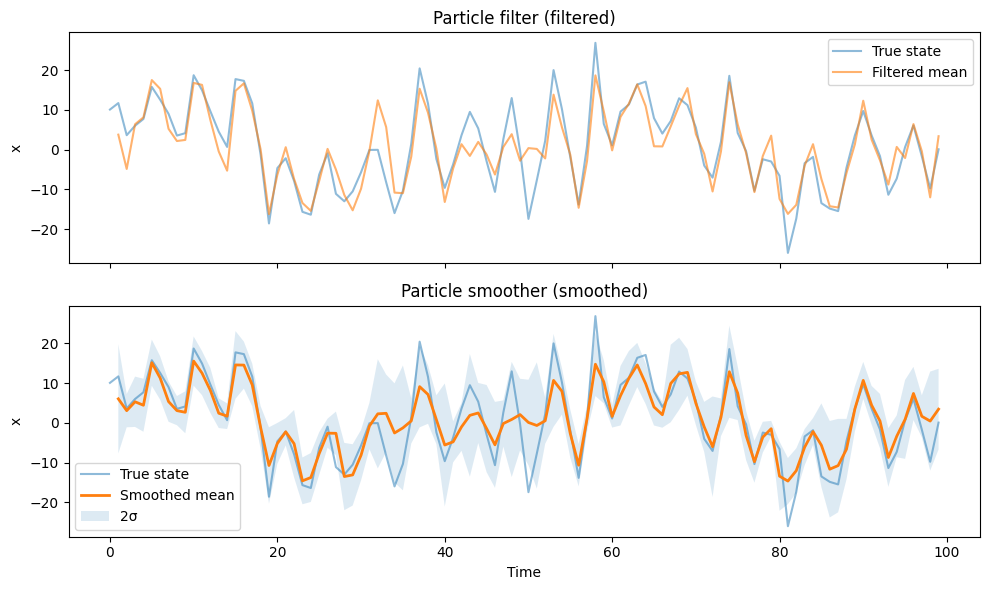

In [26]:
def transition_logdensity(x_tp1, x_t, t, tp1):
    mean = transition_fn_nl(x_t, t, tp1)
    return jax.scipy.stats.norm.logpdf(x_tp1, mean, jnp.sqrt(Q_nl[0, 0])).sum()

smoothed_particles, smoothed_log_weights = filt_pf.smooth(
    trace_pf,
    key=jax.random.PRNGKey(1),
    transition_logdensity_fn=transition_logdensity,
)

sm_mean = smoothed_particles.mean(axis=1)
sm_std = smoothed_particles.std(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(ts, x_true_nl[:, 0], alpha=0.5, label="True state")
axes[0].plot(ts_filt, pf_mean[:, 0], alpha=0.6, label="Filtered mean")
axes[0].set_ylabel("x"); axes[0].legend()
axes[0].set_title("Particle filter (filtered)")

axes[1].plot(ts, x_true_nl[:, 0], alpha=0.5, label="True state")
axes[1].plot(ts_filt, sm_mean[:, 0], linewidth=2, label="Smoothed mean")
axes[1].fill_between(ts_filt, sm_mean[:, 0] - 2*sm_std[:, 0], sm_mean[:, 0] + 2*sm_std[:, 0], alpha=0.15, label="2σ")
axes[1].set_xlabel("Time"); axes[1].set_ylabel("x"); axes[1].legend()
axes[1].set_title("Particle smoother (smoothed)")

plt.tight_layout(); plt.show()

## Comparing filters

All three nonlinear filters can be compared side by side on the same model.

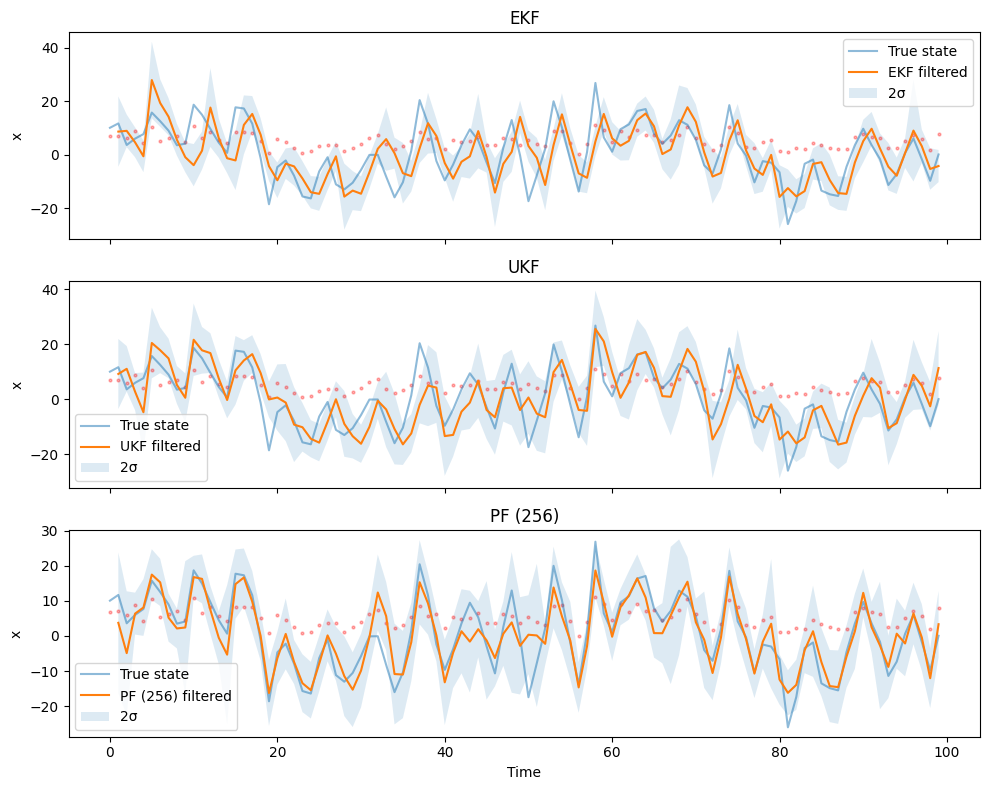

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, (name, mus, stds) in zip(axes, [
    ("EKF", mus_ekf, stds_ekf),
    ("UKF", mus_ukf, stds_ukf),
    ("PF (256)", pf_mean[:, 0], pf_std[:, 0]),
]):
    ax.plot(ts, x_true_nl[:, 0], alpha=0.5, label="True state")
    ax.plot(ts_filt, mus, label=f"{name} filtered")
    ax.fill_between(ts_filt, mus - 2*stds, mus + 2*stds, alpha=0.15, label="2σ")
    ax.scatter(ts, y_obs_nl[:, 0], s=4, color="red", alpha=0.3)
    ax.set_ylabel("x"); ax.legend()
    ax.set_title(name)

axes[-1].set_xlabel("Time")
plt.tight_layout(); plt.show()

## Verbose mode

Like `MCMC(kernel, verbose=True)`, the `Filter` runner can display a progress bar
with running log-likelihood (useful for long time series).

In [28]:
filt_verbose = Filter(kalman_filter(transition_model, observation_model), verbose=True)

# Run a longer series to see the progress bar
ts_long = jnp.arange(2000, dtype=jnp.float32)
observations_long = jnp.zeros((2000, 1))  # observations at all times
obs_mask_long = jnp.concatenate([jnp.array([False]), jnp.ones(1999, dtype=bool)])

_ = filt_verbose.filter(key, ts_long, observations_long, mu0, cov0, obs_mask=obs_mask_long)

Progress: |██████████████████████████████████████████████████| 100.00% log_likelihood: 0.14

## Filtering + Smoothing Workflow

Filter and smooth in two steps: first run `.filter()`, then pass the trace to `.smooth()`.

In [29]:
# First filter
filt_combined = Filter(kalman_filter(transition_model, observation_model))
trace_combined = filt_combined.filter(key, ts, observations, mu0, cov0, obs_mask=obs_mask)

# Then smooth
mus_s2, covs_s2 = filt_combined.smooth(trace_combined, smoother=rts_smoother)

print(f"Smoothed means shape:  {mus_s2.shape}")
print(f"Smoothed covs shape:   {covs_s2.shape}")

Smoothed means shape:  (99, 1)
Smoothed covs shape:   (99, 1, 1)


## Two API Styles: Functional vs Object-Oriented

probjax supports two programming styles for filtering:

### 1. Functional API (frozen=True)

The **functional style** treats the filter as a pure function with no internal state.
All parameters are passed explicitly to each method call. This style is:
- **Fully JIT-compatible** — methods can be `jax.jit` compiled
- **Immutable** — no side effects, easier to reason about
- **Preferred for production** — when you need maximum performance

```python
# Functional style — all arguments explicit
kernel = kalman_filter(transition_model, observation_model)
filt = Filter(kernel, frozen=True)  # default

# Each call is self-contained
trace = filt.filter(key, ts, observations, mu0, cov0, obs_mask=obs_mask)
ll = filt.log_likelihood(key, ts, observations, mu0, cov0, obs_mask=obs_mask)
```

### 2. Object-Oriented API (frozen=False)

The **OO style** stores parameters inside the filter object, making it stateful.
This is more convenient for interactive exploration but **not JIT-compatible**:

```python
# OO style — parameters stored internally
filt = Filter(kernel, frozen=False)
filt = filt.set_params(mu0=mu0, cov0=cov0)  # store initial state

# Shorter calls — parameters retrieved from self
trace = filt.filter(key, ts, observations, obs_mask=obs_mask)
ll = filt.log_likelihood(key, ts, observations, obs_mask=obs_mask)
```

**When to use each:**
- Use **functional** (`frozen=True`, default) for: production code, gradient computation, parameter optimization
- Use **OO** (`frozen=False`) for: interactive notebooks, exploration, when convenience matters more than JIT

Both APIs support the same methods — the difference is only in where parameters live.

In [ ]:
# Demonstration: both APIs produce identical results
from probjax.inference.filter_smooth import Filter

kernel = kalman_filter(transition_model, observation_model)

# Functional API (default)
filt_func = Filter(kernel, frozen=True)
trace_func = filt_func.filter(key, ts, observations, mu0, cov0, obs_mask=obs_mask)

# OO API (stateful)
filt_oo = Filter(kernel, frozen=False).set_params(mu0=mu0, cov0=cov0)
trace_oo = filt_oo.filter(key, ts, observations, obs_mask=obs_mask)

# Results are identical
print(f"Functional mean at t=10: {trace_func.states.mean[10, 0]:.4f}")
print(f"OO mean at t=10:       {trace_oo.states.mean[10, 0]:.4f}")
print(f"Results match: {jnp.allclose(trace_func.states.mean, trace_oo.states.mean)}")

## Parameter Estimation with `fit()`

The `fit()` method provides a convenient interface for **parameter learning** — estimating
unknown model parameters (transition matrices, noise covariances, etc.) from data.

**How it works:**
1. Define a **parameterized kernel** — a function that takes parameters and returns a filter kernel
2. Provide **initial parameter values** — starting point for optimization
3. `fit()` maximizes the log-likelihood using gradient-based optimization (Adam by default)

**Key features:**
- Works with any filter (Kalman, EKF, UKF, Particle)
- Supports parameter constraints (positivity for covariances, etc.)
- Returns optimized parameters and final log-likelihood
- Compatible with `frozen=True` for JIT-compiled inner loop

**Example use cases:**
- Learning unknown noise covariances `Q` and `R`
- Estimating transition dynamics from data
- System identification for physical models

In [ ]:
# Example: estimating observation noise covariance R
from functools import partial

# True model has R=0.5, but we pretend we don't know it
# We'll estimate R from the observations

def make_kernel_with_R(log_R):
    """Create a Kalman filter kernel with parameterized observation noise."""
    R_param = jnp.exp(log_R)  # ensure positivity via log-parameterization
    
    def obs_model(t):
        return C, R_param
    
    return kalman_filter(transition_model, obs_model)

# Initial guess: R is too large
log_R_init = jnp.log(2.0)  # starting guess: R=2.0

# Create a filter with the parameterized kernel
kernel_factory = lambda params: make_kernel_with_R(params['log_R'])

filt_fit = Filter(kernel_factory, frozen=True)

# Fit to data — optimize log_R to maximize likelihood
optimized_params, final_ll = filt_fit.fit(
    key,
    ts,
    observations,
    mu0,
    cov0,
    obs_mask=obs_mask,
    params_init={'log_R': log_R_init},
    num_steps=100,
    learning_rate=0.1,
)

R_estimated = jnp.exp(optimized_params['log_R'])
print(f"True R:       0.5000")
print(f"Initial R:    {jnp.exp(log_R_init):.4f}")
print(f"Estimated R:  {R_estimated:.4f}")
print(f"Final log-likelihood: {final_ll:.2f}")

## Observations

**Linear model:** The Kalman filter is exact — no approximation error. RTS smoothing refines estimates using future observations, producing tighter uncertainty bands.

**Nonlinear model:**
- **EKF** linearizes via Jacobians — fast but can diverge on highly nonlinear models.
- **UKF** propagates sigma points — more robust than EKF, no Jacobians needed.
- **Particle filter** is nonparametric — handles arbitrary nonlinearities but requires more particles for high-dimensional states.

**API design:** The `Filter` runner follows the same pattern as `MCMC` and `SMC` —
construct with a kernel, then call `.filter()`, `.smooth()`, `.log_likelihood()`.  This
makes it easy to swap filters without changing orchestration code.

**Programming style:** Use **functional API** (`frozen=True`, default) for JIT compatibility and
parameter optimization. Use **OO API** (`frozen=False`) for convenience in interactive exploration.

**Parameter learning:** The `fit()` method enables maximum-likelihood estimation of unknown model
parameters, making it easy to learn noise covariances or dynamics directly from data.